# Task 6: K‑Nearest Neighbors (KNN) Classification – Iris Dataset (Enhanced)

This notebook implements the K‑Nearest Neighbors algorithm for classifying iris flowers into three species (*Setosa*, *Versicolor*, *Virginica*). It covers data preprocessing, normalisation, model training, hyperparameter tuning, evaluation, cross‑validation, and visualisation of decision boundaries.

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit‑learn

---

### Cell 1: Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

# Set plot style
sns.set_theme(style="whitegrid")

# Load Iris dataset
df = pd.read_csv('Iris.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Cell 2: Exploratory Data Analysis
- Check for missing values
- Visualise feature distributions and correlations

Missing values:
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Class mapping: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


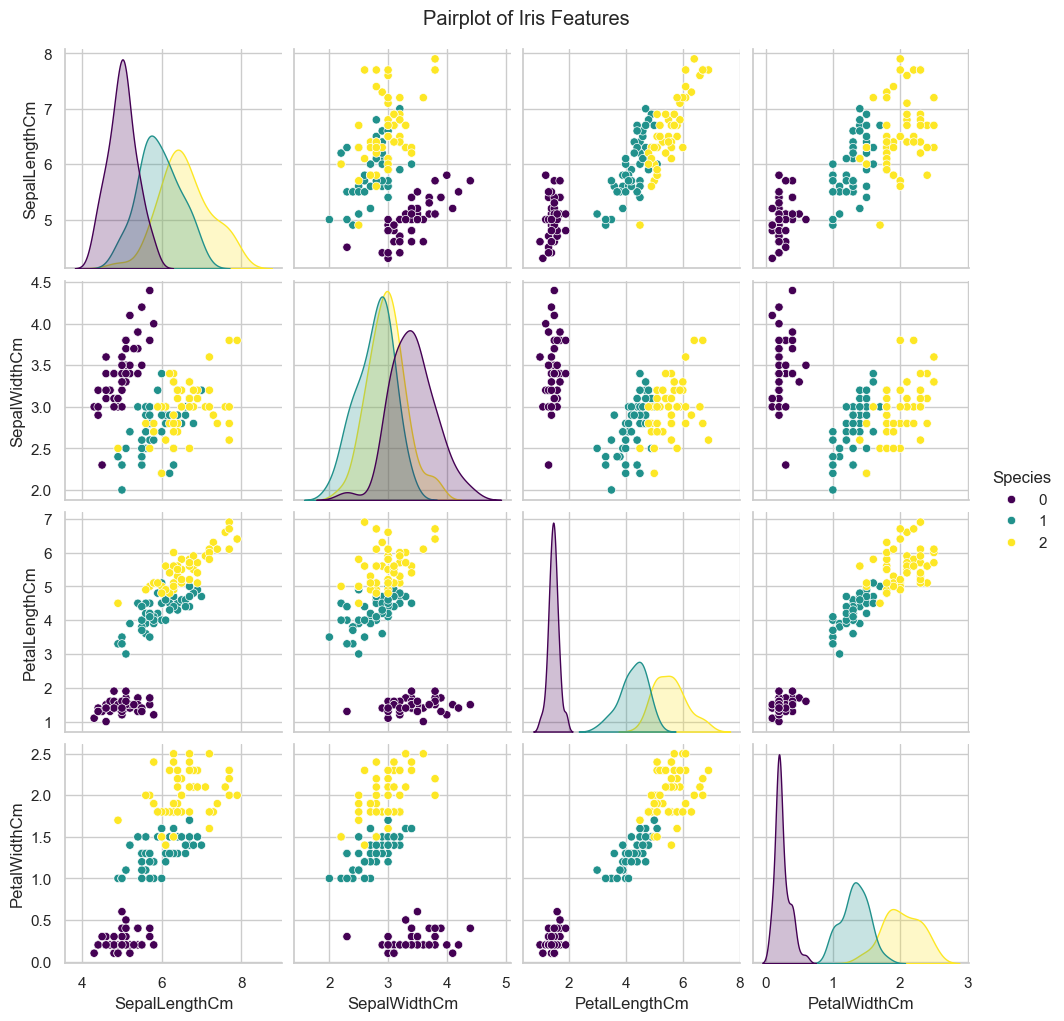

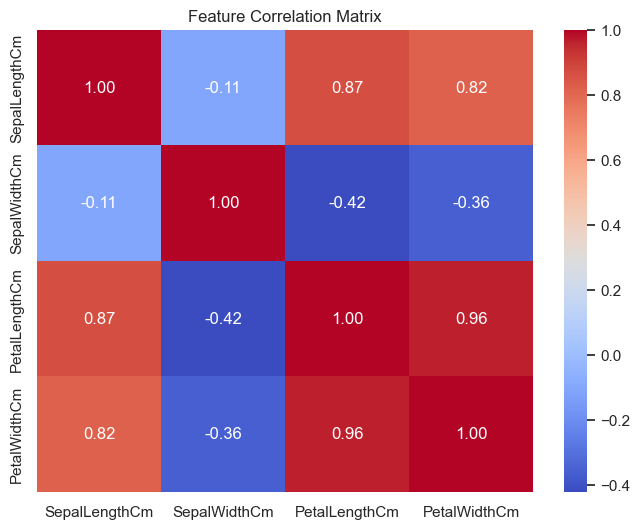

In [2]:
# Check missing values
print("Missing values:\n", df.isnull().sum())

# Drop 'Id' column if present
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Encode target labels
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])
print("\nClass mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Pairplot to visualise separability
sns.pairplot(df, hue='Species', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot of Iris Features', y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('Species', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

### Cell 3: Data Preprocessing
- Separate features (X) and target (y).
- Split into training (80%) and testing (20%) sets.
- **Normalise features** – essential for KNN.

In [3]:
# Separate features and target
X = df.drop('Species', axis=1)
y = df['Species']

# Train‑test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print("\nFeature means after scaling (should be ~0):", X_train_scaled.mean(axis=0))
print("Feature stds after scaling (should be ~1):", X_train_scaled.std(axis=0))

Training set size: 120
Test set size: 30

Feature means after scaling (should be ~0): [-1.36927506e-16  4.55191440e-16 -9.06682137e-17  5.36607795e-17]
Feature stds after scaling (should be ~1): [1. 1. 1. 1.]


### Cell 4: Baseline KNN (k = 5) and Evaluation

KNN (k=5) Test Accuracy: 0.9333

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



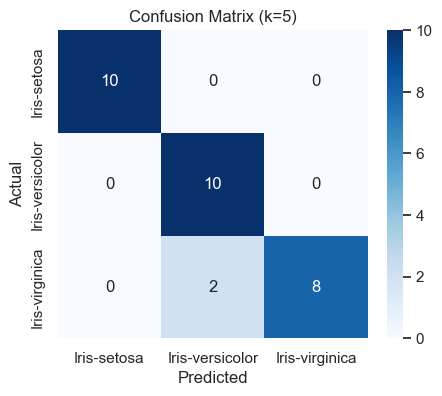

In [4]:
knn_default = KNeighborsClassifier(n_neighbors=5)
knn_default.fit(X_train_scaled, y_train)
y_pred_default = knn_default.predict(X_test_scaled)
acc_default = accuracy_score(y_test, y_pred_default)

print(f"KNN (k=5) Test Accuracy: {acc_default:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_default, target_names=le.classes_))

# Confusion matrix
cm_default = confusion_matrix(y_test, y_pred_default)
plt.figure(figsize=(5,4))
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix (k=5)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

### Cell 5: Effect of Different k Values (with Cross‑Validation Error Bars)

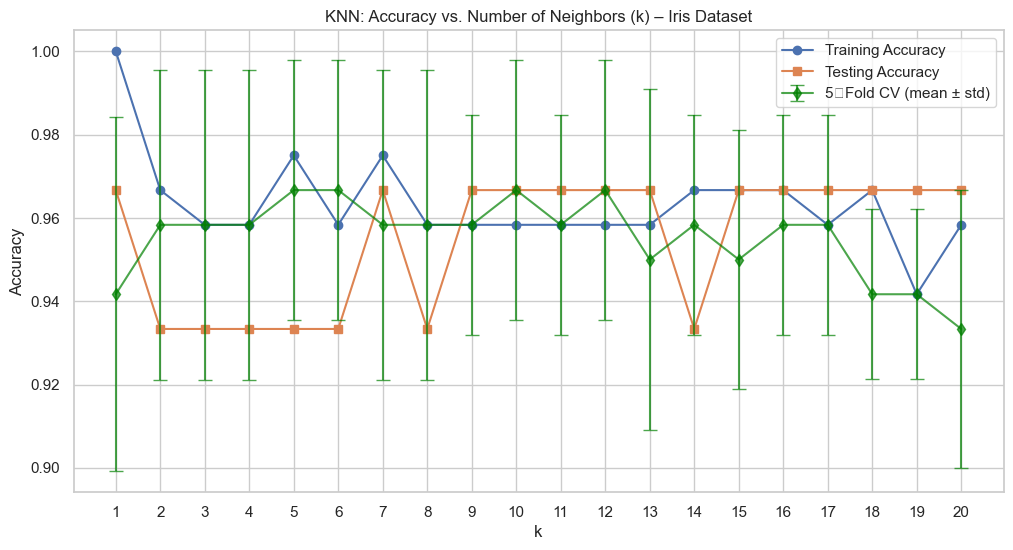

Best k by test accuracy: 1 (accuracy = 0.9667)
Best k by CV mean: 5 (CV accuracy = 0.9667)


In [5]:
k_range = range(1, 21)
train_acc = []
test_acc = []
cv_mean = []
cv_std = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_acc.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, knn.predict(X_test_scaled)))
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    cv_mean.append(scores.mean())
    cv_std.append(scores.std())

# Plot with error bars for CV
plt.figure(figsize=(12, 6))
plt.plot(k_range, train_acc, label='Training Accuracy', marker='o')
plt.plot(k_range, test_acc, label='Testing Accuracy', marker='s')
plt.errorbar(k_range, cv_mean, yerr=cv_std, label='5‑Fold CV (mean ± std)', 
             fmt='-d', capsize=5, color='green', alpha=0.7)
plt.title('KNN: Accuracy vs. Number of Neighbors (k) – Iris Dataset')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.xticks(k_range)
plt.legend()
plt.grid(True)
plt.show()

best_k = k_range[np.argmax(test_acc)]
print(f"Best k by test accuracy: {best_k} (accuracy = {max(test_acc):.4f})")
print(f"Best k by CV mean: {k_range[np.argmax(cv_mean)]} (CV accuracy = {max(cv_mean):.4f})")

### Cell 6: Hyperparameter Tuning with GridSearchCV
Search over different `k`, `weights`, and `metric`.

In [6]:
param_grid = {
    'n_neighbors': range(1, 21),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'chebyshev']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross‑validation accuracy:", grid_search.best_score_)

best_knn = grid_search.best_estimator_
y_pred_tuned = best_knn.predict(X_test_scaled)
print(f"Test accuracy with tuned model: {accuracy_score(y_test, y_pred_tuned):.4f}")

Best parameters: {'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'distance'}
Best cross‑validation accuracy: 0.975
Test accuracy with tuned model: 0.9667


### Cell 7: Learning Curve (Diagnose Bias/Variance)

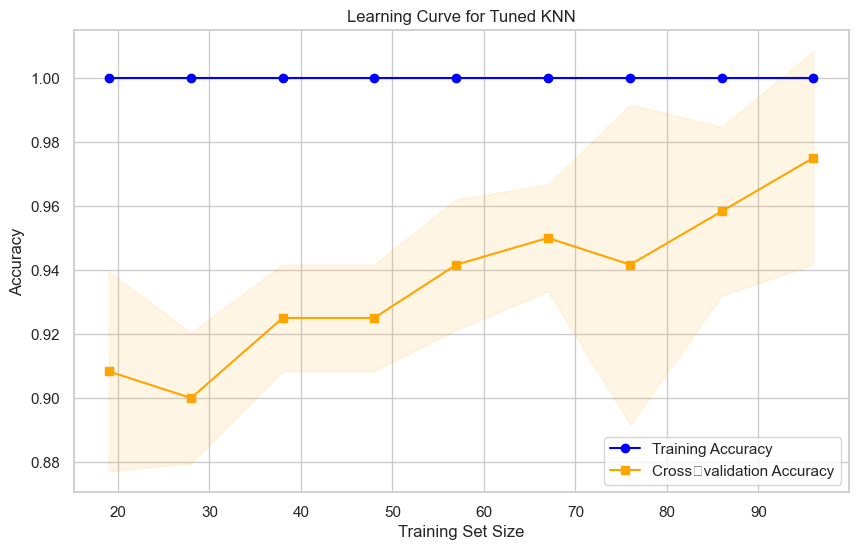

In [7]:
train_sizes, train_scores, test_scores = learning_curve(
    best_knn, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10,6))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Accuracy')
plt.plot(train_sizes, test_mean, 's-', color='orange', label='Cross‑validation Accuracy')
plt.title('Learning Curve for Tuned KNN')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid(True)
plt.show()

### Cell 8: Compare KNN with a Decision Tree Classifier

In [8]:
dt = DecisionTreeClassifier(random_state=42, max_depth=3)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Test Accuracy: {acc_dt:.4f}")
print(f"Tuned KNN Test Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")

# Summary table
comparison = pd.DataFrame({
    'Model': ['KNN (default k=5)', 'KNN (tuned)', 'Decision Tree (max_depth=3)'],
    'Test Accuracy': [acc_default, accuracy_score(y_test, y_pred_tuned), acc_dt]
})
print("\nModel Comparison:")
print(comparison)

Decision Tree Test Accuracy: 0.9667
Tuned KNN Test Accuracy: 0.9667

Model Comparison:
                         Model  Test Accuracy
0            KNN (default k=5)       0.933333
1                  KNN (tuned)       0.966667
2  Decision Tree (max_depth=3)       0.966667


### Cell 9: Visualising Decision Boundaries (2D PCA)

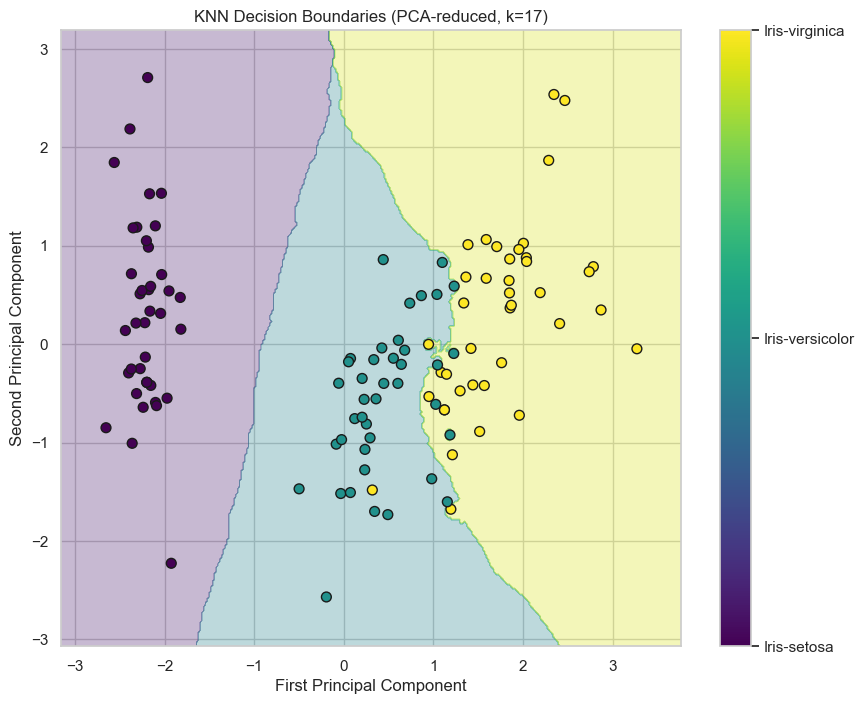

In [9]:
# PCA to 2 components
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

# Train KNN on PCA-reduced data (for visualisation)
knn_pca = KNeighborsClassifier(**grid_search.best_params_)
knn_pca.fit(X_train_pca, y_train)

# Create mesh grid
x_min, x_max = X_train_pca[:, 0].min() - 0.5, X_train_pca[:, 0].max() + 0.5
y_min, y_max = X_train_pca[:, 1].min() - 0.5, X_train_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train,
                      cmap='viridis', edgecolor='k', s=50)
plt.title(f'KNN Decision Boundaries (PCA-reduced, k={grid_search.best_params_["n_neighbors"]})')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
cbar = plt.colorbar(scatter, ticks=[0,1,2])
cbar.set_ticklabels(le.classes_)
plt.show()

## Summary of Enhancements

Compared to the original notebook, this version adds:

1. **Exploratory Data Analysis** – Pairplot and correlation heatmap.
2. **Hyperparameter tuning** with `GridSearchCV` (k, weights, metric).
3. **Learning curve** to diagnose bias/variance.
4. **Comparison** with a Decision Tree classifier.
5. **Cross‑validation error bars** on the k‑accuracy plot.

These improvements make the analysis more thorough and professional, suitable for a data science project.